<a href="https://colab.research.google.com/github/reveondivad/ExData_Plotting1/blob/master/Copy_of_Analyzing_Handwriting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwriting Recognition of Alphabetic Letters
* The purpose of this program is to teach a machine to recognize handwritten lettering
* It has two phases. First a training session will present each letter from a sample dataset
* Second, a testing session will predict each letter even though its never been presented to the program
* Handwriting recognition appears across the world - in different languages - and makes possible high-speed digitization of handwitten notes, checks, signed documents, and even life-saving medical prescriptions

# What is training data?
* MNIST is the leading dataset of handwritten letters
* The original was number digits only. It  was produced by the National Institute of Standards and Technology (or NIST) in Colorado for scoring computer programs
* The data contains 10,000+ example of different letters in all handwriting styles

In [1]:
#Step 1.1. Get the data from a repository
!git clone https://github.com/sorki/python-mnist
!./python-mnist/bin/emnist_get_data.sh
!pip3 install emnist 
from emnist import extract_training_samples
print("Imported the EMNIST libraries we needed!")


Cloning into 'python-mnist'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 246 (delta 1), reused 2 (delta 0), pack-reused 240
Receiving objects: 100% (246/246), 47.14 KiB | 482.00 KiB/s, done.
Resolving deltas: 100% (119/119), done.
/content/emnist_data /content
--2022-04-23 17:33:46--  http://www.itl.nist.gov/iaui/vip/cs_links/EMNIST/gzip.zip
Resolving www.itl.nist.gov (www.itl.nist.gov)... 129.6.13.19, 2610:20:6b01:4::175
Connecting to www.itl.nist.gov (www.itl.nist.gov)|129.6.13.19|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.itl.nist.gov/iaui/vip/cs_links/EMNIST/gzip.zip [following]
--2022-04-23 17:33:47--  https://www.itl.nist.gov/iaui/vip/cs_links/EMNIST/gzip.zip
Connecting to www.itl.nist.gov (www.itl.nist.gov)|129.6.13.19|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 561753746 (536M) [application/zip]
Savin

# Split the data between Training and Testing
* A key step in preparing machine learning is to divide the data into two groups, one to learn from, and another to test on. 

In [2]:
# Step 1.2 Preprocessing to extract traing and test sets
# other handwriting can be numbers ['balanced', 'byclass', 'bymerge', 'digits', 'letters', 'mnist']
X, y = extract_training_samples('letters')
# divide by 255 which is the gray-scale pixel range from 0-255. Black is zero, white is 255.
X = X / 255.   
# set aside 15% of the data for testing
X_train, X_test = X[:60000], X[60000:70000] 
y_train, y_test = y[:60000], y[60000:70000]
# make an image for 28x28 pixels  = 784
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
print("Extracted our samples and divided our training and testing data sets.")

Extracted our samples and divided our training and testing data sets.


In [3]:
#shape of dataset
print('X_train: ' + str(X_train.shape))
print('y_train: ' + str(y_train.shape))
print('X_test:  '  + str(X_test.shape))
print('y_test:  '  + str(y_test.shape))

X_train: (60000, 784)
y_train: (60000,)
X_test:  (10000, 784)
y_test:  (10000,)


Image Label:v


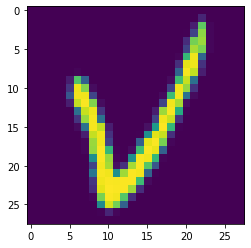

In [25]:
img_index=8
img = X_train[img_index]
print("Image Label:" + str(chr(y_train[img_index]+96)))  
plt.imshow(img.reshape((28,28)));

In [26]:
X_train[img_index]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.10196078, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [18]:
str(chr(y_train[1]+96))

'g'

# Explore the data examples

* The training set contains 60k images and the testing set contains 10k images.
* The training input vector is of the dimension [60000 X 28 X 28].
* The training output vector is of the dimension [60000 X 1].
* Each individual input vector is of the dimension [28 X 28].
* Output vector is of the dimension [1].

* reshape the data into 2D, 28x28 sized images instead of a 1D 784 array

Image Label:t


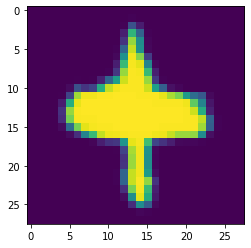

In [6]:
#Step 1.3  Pick a random letter from the training data
import matplotlib.pyplot as plt
import random

img_index = random.randrange(0, len(X_train)) #120 # <<<<<You can update this value to look @ other images. 
img = X_train[img_index]
print("Image Label:" + str(chr(y_train[img_index]+96)))  
plt.imshow(img.reshape((28,28)));

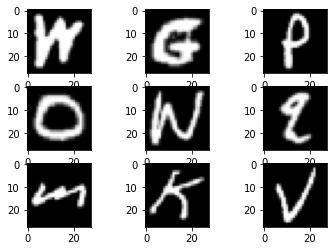

In [12]:
from matplotlib import pyplot
for i in range(9):  
  pyplot.subplot(330 + 1 + i)
  img_index = i # <<<<<You can shift this value to look @ other images. 
  img = X_train[img_index]
  #print(str(chr(y_train[img_index]+96)))
  pyplot.imshow(img.reshape(28,28), cmap=pyplot.get_cmap('gray'))

# Machine Learning Model
* We apply a standard model for the neuron
* Called Multi-Layer Perceptron (MLP), which has one input layer where the image is presented as pixel values
* A middle or "hidden" layer is used to fit curves
* An output layer is where the letter is predicted

* Learning occurs in the perceptron by changing connection weights after each piece of data is processed, based on the amount of error in the output compared to the expected result.

* Backpropogation is also a part of it where the recall goes back through the network to be re-tested in order to increase the % of correct tests. 

<img src="https://static.javatpoint.com/tutorial/tensorflow/images/multi-layer-perceptron-in-tensorflow.png">

In [13]:
# Step 2
# Now let's import the ML libraries we need!
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier

#This creates 1st MLP with 1 hidden layer of 50 neurons and set it to run through the data 20 times! :)
mlpl = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, alpha=1e-4,
                     solver='sgd', verbose=10, tol=1e-4, random_state=1,
                     learning_rate_init=.1)
print("Created our first MLP network.")

Created our first MLP network.


# Score Accuracies > 84% on unseen test data
* Training set score: 0.886500
* Test set score: 0.840800

In [14]:
#Step 3.1
mlpl.fit(X_train, y_train)
print("Training set score: %f" % mlpl.score(X_train, y_train))
print("Test set score: %f" % mlpl.score(X_test, y_test))

Iteration 1, loss = 1.06351395
Iteration 2, loss = 0.64844650
Iteration 3, loss = 0.56103245
Iteration 4, loss = 0.51987725
Iteration 5, loss = 0.49182099
Iteration 6, loss = 0.47301057
Iteration 7, loss = 0.45839220
Iteration 8, loss = 0.44603836
Iteration 9, loss = 0.43479721
Iteration 10, loss = 0.42809575
Iteration 11, loss = 0.41639233
Iteration 12, loss = 0.40782908
Iteration 13, loss = 0.40548360
Iteration 14, loss = 0.39965983
Iteration 15, loss = 0.39296832
Iteration 16, loss = 0.38883219
Iteration 17, loss = 0.38393955
Iteration 18, loss = 0.37948343
Iteration 19, loss = 0.37307616
Iteration 20, loss = 0.37166732


/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:696: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  ConvergenceWarning,


Training set score: 0.886500
Test set score: 0.840800


* codes_list of shape (n_layers - 1,)
* * The **fifth** element in the list represents the weight matrix corresponding to layer i.

In [28]:
print("Each layer has " + str(len(mlpl.coefs_[0])) + " weights that the MLP solved for")

Each layer has 784 weights that the MLP solved for


# Visualize a sample layer of neuron weights

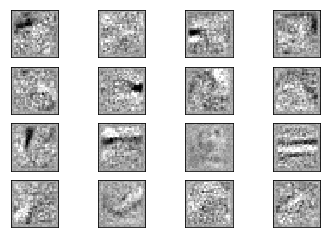

In [27]:
fig, axes = plt.subplots(4, 4)  # 4 x 4 images in panel
# use global min / max to ensure all weights are shown on the same scale
vmin, vmax = mlpl.coefs_[0].min(), mlpl.coefs_[0].max()
for coef, ax in zip(mlpl.coefs_[0].T, axes.ravel()):
    ax.matshow(coef.reshape(28, 28), cmap=plt.cm.gray, vmin=0.5 * vmin, vmax=0.5 * vmax)
    ax.set_xticks(())
    ax.set_yticks(())

plt.show()

# Compare predicted letters with actual ones
* called an "error" or "confusion" matrix
* all 26 letters are shown on the x-y axis
* predicted is X, actual is Y
* a diagonal indicates correct prediction for that letter
* look at 12th letter ("l" vs. "i") and "q"
* brighter=more accurate



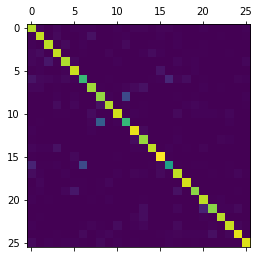

In [29]:
#Step 3.2
#First let's initiate a list with all predicted values:
y_pred = mlpl.predict(X_test)

#Now let's visualize the errors between the predictions and the actual labels using a confusion matrix.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix (y_test, y_pred)
plt.matshow(cm);

# Show the confusing letters that are closely matched in handwriting, like "l" and "i"

There was 109 times that the letter l was predicted to be the letter i.


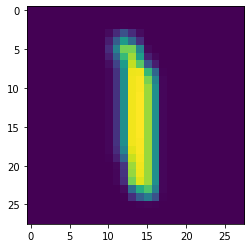

In [35]:
#Step 3.3
#You can change network you think neural network has confused.
predicted_letter = 'i'
actual_letter = 'l'
#This code counts all mistakes in letters above.
mistake_list = []
for i in range(len(y_test)):
  if (y_test[i]==(ord(actual_letter) - 96) and y_pred[i]==(ord(predicted_letter) - 96)):
    mistake_list.append(i)
print("There was "+str(len(mistake_list)) + " times that the letter " + actual_letter+ " was predicted to be the letter "+predicted_letter+".")
mistake_to_show = 4
if (len(mistake_list)>mistake_to_show):
  img = X_test[mistake_list[mistake_to_show]]
  plt.imshow(img.reshape(28,28))
else:
  print("Couldn't show mistake number "+str(mistake_to_show+1)+" because there were only "+str(len(mistake_list))+" mistakes to show!")

# Test if bigger networks show more accurate letter predictions
* The 1st MLP had 1 hidden layer of 50 neurons and ran through the data 20 times. **84% Accurate**
* * Training set score: 0.886500
* * Test set score: 0.840800
* This 2nd MLP has 5 hidden layers of 100 neurons and runs through the data 50 times. **88% Accurate**
* * Training set score: 0.942133
* * Test set score: 0.885300



In [44]:
#Step 3.4
# Let's change some values in below statement to run and see how performance is affected!
mlp2 = MLPClassifier(hidden_layer_sizes=(100,100,100,100,100), max_iter=50, alpha=1e-4,
                     solver='sgd', verbose=10, tol=1e-4, random_state=1,
                     learning_rate_init=.1)
mlp2.fit(X_train, y_train)
print("Training set score: %f"% mlp2.score(X_train, y_train))
print("Test set score: %f"% mlp2.score(X_test, y_test))

Iteration 1, loss = 1.15599672
Iteration 2, loss = 0.54834774
Iteration 3, loss = 0.44784035
Iteration 4, loss = 0.39865207
Iteration 5, loss = 0.36308811
Iteration 6, loss = 0.33567397
Iteration 7, loss = 0.31904877
Iteration 8, loss = 0.29485588
Iteration 9, loss = 0.27846574
Iteration 10, loss = 0.26938228
Iteration 11, loss = 0.25802023
Iteration 12, loss = 0.25788282
Iteration 13, loss = 0.24536935
Iteration 14, loss = 0.23723836
Iteration 15, loss = 0.23099846
Iteration 16, loss = 0.22170512
Iteration 17, loss = 0.22529625
Iteration 18, loss = 0.21631371
Iteration 19, loss = 0.21638970
Iteration 20, loss = 0.21005670
Iteration 21, loss = 0.21102943
Iteration 22, loss = 0.20452900
Iteration 23, loss = 0.20898563
Iteration 24, loss = 0.20109377
Iteration 25, loss = 0.19006968
Iteration 26, loss = 0.19761229
Iteration 27, loss = 0.19347616
Iteration 28, loss = 0.19347809
Iteration 29, loss = 0.20051092
Iteration 30, loss = 0.18964287
Iteration 31, loss = 0.18354442
Iteration 32, los

/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:696: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  ConvergenceWarning,


Training set score: 0.942133
Test set score: 0.885300


In [36]:
#Step 3.4a
# Let's change some values in below statement to run and see how performance is affected!
# we added a single layer to make 6 total, and we made a 50 neuron layer
# mlpl = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, alpha=1e-4,
#                     solver='sgd', verbose=10, tol=1e-4, random_state=1,
#                     learning_rate_init=.1)
mlp3 = MLPClassifier(hidden_layer_sizes=(100,100,100,100,100,50), max_iter=20, alpha=1e-4,
                     solver='sgd', verbose=10, tol=1e-4, random_state=1,
                     learning_rate_init=.1)
mlp3.fit(X_train, y_train)
print("Training set score: %f"% mlp3.score(X_train, y_train))
print("Test set score: %f"% mlp3.score(X_test, y_test))

Iteration 1, loss = 1.59951869
Iteration 2, loss = 0.68033413
Iteration 3, loss = 0.54055846
Iteration 4, loss = 0.47808363
Iteration 5, loss = 0.42684952
Iteration 6, loss = 0.39619482
Iteration 7, loss = 0.37810653
Iteration 8, loss = 0.35024501
Iteration 9, loss = 0.33425409
Iteration 10, loss = 0.32311107
Iteration 11, loss = 0.30559658
Iteration 12, loss = 0.29701652
Iteration 13, loss = 0.29223073
Iteration 14, loss = 0.27998226
Iteration 15, loss = 0.27129356
Iteration 16, loss = 0.26658309
Iteration 17, loss = 0.26117279
Iteration 18, loss = 0.25263067
Iteration 19, loss = 0.25185152
Iteration 20, loss = 0.24349032


/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:696: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  ConvergenceWarning,


Training set score: 0.926767
Test set score: 0.883700


# Try to recognize handwriting in 100 scanned images or photographs
* see if we can read a handwritten story by predicting the letters in order


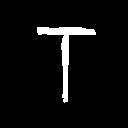

In [38]:
#Step 4.1
#Pulls scanned data set from GitHub
!git clone https://github.com/crash-course-ai/lab1-neural-networks.git
#!git pull
!ls lab1-neural-networks/letters_mod
!cd /content/lab1-neural-networks/letters_mod
!pwd

fatal: destination path 'lab1-neural-networks' already exists and is not an empty directory.
00.jpg	10.jpg	20.jpg	30.jpg	40.jpg	50.jpg	60.jpg	70.jpg	80.jpg	90.jpg
01.jpg	11.jpg	21.jpg	31.jpg	41.jpg	51.jpg	61.jpg	71.jpg	81.jpg	91.jpg
02.jpg	12.jpg	22.jpg	32.jpg	42.jpg	52.jpg	62.jpg	72.jpg	82.jpg	92.jpg
03.jpg	13.jpg	23.jpg	33.jpg	43.jpg	53.jpg	63.jpg	73.jpg	83.jpg	93.jpg
04.jpg	14.jpg	24.jpg	34.jpg	44.jpg	54.jpg	64.jpg	74.jpg	84.jpg	94.jpg
05.jpg	15.jpg	25.jpg	35.jpg	45.jpg	55.jpg	65.jpg	75.jpg	85.jpg	95.jpg
06.jpg	16.jpg	26.jpg	36.jpg	46.jpg	56.jpg	66.jpg	76.jpg	86.jpg	96.jpg
07.jpg	17.jpg	27.jpg	37.jpg	47.jpg	57.jpg	67.jpg	77.jpg	87.jpg	97.jpg
08.jpg	18.jpg	28.jpg	38.jpg	48.jpg	58.jpg	68.jpg	78.jpg	88.jpg	98.jpg
09.jpg	19.jpg	29.jpg	39.jpg	49.jpg	59.jpg	69.jpg	79.jpg	89.jpg	99.jpg
/content


In [39]:
# Puts all the data in the "files" variable
import os
path, dirs, files = next(os.walk("/content/lab1-neural-networks/letters_mod/"))
files.sort()
print(files)

['00.jpg', '01.jpg', '02.jpg', '03.jpg', '04.jpg', '05.jpg', '06.jpg', '07.jpg', '08.jpg', '09.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jpg', '40.jpg', '41.jpg', '42.jpg', '43.jpg', '44.jpg', '45.jpg', '46.jpg', '47.jpg', '48.jpg', '49.jpg', '50.jpg', '51.jpg', '52.jpg', '53.jpg', '54.jpg', '55.jpg', '56.jpg', '57.jpg', '58.jpg', '59.jpg', '60.jpg', '61.jpg', '62.jpg', '63.jpg', '64.jpg', '65.jpg', '66.jpg', '67.jpg', '68.jpg', '69.jpg', '70.jpg', '71.jpg', '72.jpg', '73.jpg', '74.jpg', '75.jpg', '76.jpg', '77.jpg', '78.jpg', '79.jpg', '80.jpg', '81.jpg', '82.jpg', '83.jpg', '84.jpg', '85.jpg', '86.jpg', '87.jpg', '88.jpg', '89.jpg', '90.jpg', '91.jpg', '92.jpg', '93.jpg', '94.jpg', '95.jpg', '96.jpg', '97.jpg', '98.jpg', '99.jpg']

# Explore the image scans

Imported the scanned images.


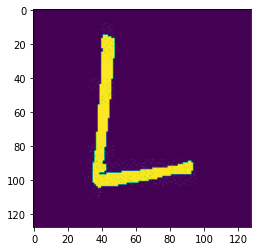

In [41]:
#Step 4.2
#These libraries let us scan for, resize, and reshape these.
import cv2
import matplotlib.pyplot as plt

handwritten_story = []
for i in range(len(files)):
  img = cv2.imread("/content/lab1-neural-networks/letters_mod/"+files[i],cv2.IMREAD_GRAYSCALE)
  handwritten_story.append(img)

print("Imported the scanned images.")
plt.imshow(handwritten_story[7]);

# Put the pixels into a table (28x28) to make predictions
* one problem is how some scans are blank to represent spaces between words

In [45]:
#Step 4.3
#These are libraries where we need to do math on some images.
#to be able to give them proper MLP in right format and to resize it to 28 by 28 pixels.
import numpy
import cv2
# loop over each letter in our story
typed_story = ""
for letter in handwritten_story:
    letter = cv2.resize(letter, (28,28), interpolation = cv2.INTER_CUBIC)
    single_item_array = (numpy.array(letter)).reshape(1,784)
    prediction = mlp2.predict(single_item_array)
    typed_story = typed_story + str(chr(prediction[0]+96))  # str(chr(y_train[img_index]+96)))
print("Conversion to typed story complete!")
print(typed_story)

Conversion to typed story complete!
tkejfkultjtnjourjpowerjsvpplfesjijfflljinjldvejthejwkyjyqurjaktteryjoersjskpwkyjknojthenjklljktjpncr


# What to do about spaces between words?
* Let's set a conditional if-then to handle word spaces

In [46]:
# checks to see if image is blank space or letter

typed_story = ""
for letter in handwritten_story:
  # resize each 125x125 image to thumbnail 28x28 pixels
  letter = cv2.resize(letter, (28,28), interpolation = cv2.INTER_CUBIC)
  # add the pixels to our table, rows and columns
  total_pixel_value=0
  for j in range (28):
    for k in range (28):
      total_pixel_value+= letter[j,k]
  # add the pixels and if all black (0), then not a letter
  if total_pixel_value < 20:
    typed_story = typed_story + " "
  else: #IF NOT, then must be a real letter
    single_item_array = (numpy.array(letter)).reshape(1,784)
    prediction = mlp2.predict(single_item_array)
    typed_story = typed_story + str(chr(prediction[0]+96))
print("Conversion to typed story complete!")
print(typed_story)

Conversion to typed story complete!
tke fkult tn our power svpplfes i ffll in ldve the wky yqur akttery oers skpwky kno then kll kt pncr


# Improve the image quality for better prediction accuracy
* Resizing with smarter blurring and finding regions of interest around the center of the bigger images

In [68]:
#Step 4.4
processed_story = []

for img in handwritten_story:
  #s1 Apply Gaussian blur filter
  img = cv2.GaussianBlur(img,(7,7),0)
  #s2 and 3 Extract Region of Interest in Image and Center in square
  points = cv2.findNonZero(img) # if 0 then it must be black
  x, w, y, h = cv2.boundingRect(points) # width, height, position x,y
  if (w>0 and h>0):
    if w>h:
      y=y-(w-h)//2
      img = img[y:y+h, x:x+h]
    else:
      x=x-(h-w)//2
      img = img[y:y+h, x:x+h]
  #s4 Resize and resample for 28 by 28
  #img = img/255
  #img = img.reshape((28,28))
  img = cv2.resize(letter, (28,28), interpolation = cv2.INTER_CUBIC)
  img = img/255
  img = img.reshape((28,28))
  #print(img)
  #s5 Normalize pixels and reshape before adding new story array!
  processed_story.append(img)

print("Processed scanned images!")

Processed scanned images!


In [104]:
#Step 4.4
processed_story = []

#letter = cv2.resize(letter, (28,28), interpolation = cv2.INTER_CUBIC)
#    single_item_array = (numpy.array(letter)).reshape(1,784)
#    prediction = mlp2.predict(single_item_array)
#    typed_story = typed_story + str(chr(prediction[0]+96))  # str(chr(y_train[img_index]+96)))

for img in handwritten_story:
  #s1 Apply Gaussian blur filter
  img = cv2.GaussianBlur(img,(7,7),0)
  #s2 and 3 Extract Region of Interest in Image and Center in square
  points = cv2.findNonZero(img) # if 0 then it must be black
  # x, w, y, h = cv2.boundingRect(points) # width, height, position x,y
  x,y,w,h= cv2.boundingRect(points) # width, height, position x,y
  if (w>0 and h>0):
    if w>h:  
      y=y-(w-h)//2
      img = img[y:y+h, x:x+h]
    else: 
      x=x-(h-w)//2
      img = img[y:y+h, x:x+h]
  #s4 Resize and resample for 28 by 28
  img = cv2.resize(img, (28,28), interpolation = cv2.INTER_CUBIC)
  img = img/255
  img = img.reshape((28,28))
  #print(img)
  #s5 Normalize pixels and reshape before adding new story array!
  processed_story.append(img)

print("Processed scanned images!")

Processed scanned images!


In [105]:
print("The story has " + str(len(processed_story)) + " letters or spaces")

The story has 100 letters or spaces


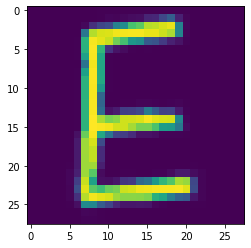

In [115]:
img_index = random.randrange(0, len(processed_story))
plt.imshow(processed_story[img_index]);

In [118]:
better_story = ""
for letter in processed_story:
    letter = cv2.resize(letter, (28,28), interpolation = cv2.INTER_CUBIC)   
    total_pixel_value=0
    for j in range (28):
      for k in range (28):
        total_pixel_value+= letter[j,k]
        # add the pixels and if all black (0), then not a letter
    if total_pixel_value < 20:
      better_story = better_story + " "
    else: #IF NOT, then must be a real letter
      single_item_array = (numpy.array(letter)).reshape(1,784)
      prediction = mlp2.predict(single_item_array)
      better_story = better_story + str(chr(prediction[0]+96))
print("Conversion to better story complete!")
print(better_story)

Conversion to better story complete!
the fault tn cur pcwer suppltes i fell in love the way your battery dies slowly and then all at once


In [117]:
better_story = ""
for letter in processed_story:
    letter = cv2.resize(letter, (28,28), interpolation = cv2.INTER_CUBIC)   
    prediction = mlp2.predict(single_item_array)
    better_story = better_story + str(chr(prediction[0]+96))
print("Conversion to better story complete!")
print(better_story)

Conversion to better story complete!
eeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee
